# 🚀 Setup — Run this cell first

This cell does everything automatically:
- Installs required packages
- Downloads all data files from GitHub

**Just run it once and then run all remaining cells normally.**

In [1]:
# ── Install packages ────────────────────────────────────────────────────────
!pip install xgboost catboost --quiet

# ── Download all data files from GitHub ─────────────────────────────────────
!git clone https://github.com/Akash251041/AI---Driven-calculated-bandgap-datacuration-in-materials-Project-based-onknown-experimental-data.git --quiet

# ── Set data directory ───────────────────────────────────────────────────────
import os
DATA_DIR = 'AI---Driven-calculated-bandgap-datacuration-in-materials-Project-based-onknown-experimental-data'

print("✅ Setup complete! Files available:")
print([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])

fatal: destination path 'AI---Driven-calculated-bandgap-datacuration-in-materials-Project-based-onknown-experimental-data' already exists and is not an empty directory.
✅ Setup complete! Files available:
['general_mp.csv', 'unary_mp.csv', 'binary_mp.csv', 'ternary_mp.csv', 'unary_exp.csv', 'quaternary_mp.csv', 'ternary_exp.csv', 'binary_exp.csv', 'Elements_DB.csv', 'general_exp.csv', 'quaternary_exp.csv']


# Binary Compounds Band Gap Prediction

**Project:** AI-Driven Calculated Bandgap Data Curation in Materials Project Based on Known Experimental Data  
**Author:** Akash Rajeshbhai Vaghela  
**Institution:** Ruhr-Universität Bochum — Department of Materials Discovery and Interfaces  
**Supervisors:** Prof. Dr.-Ing. Alfred Ludwig · Dr. Victor Dudarev

---

## Notebook Overview

This notebook builds a machine learning pipeline to predict the **experimental band gaps** of **binary compounds inorganic compounds** using composition-based feature vectors (CBFVs).

| Step | Description |
|------|-------------|
| 1 | Load calculated & experimental datasets |
| 2 | Load elemental properties database |
| 3 | Merge datasets on formula + crystal system |
| 4 | Exploratory data analysis (band gap distributions) |
| 5 | Formula parsing → composition dictionaries |
| 6 | Feature engineering (276 CBFV features) |
| 7 | Data preparation & train/test split |
| 8 | Model benchmarking — 12 algorithms via 10-Fold CV |
| 9 | Feature importance analysis |
| 10 | Parity plot (predicted vs. experimental) |
| 11 | Monte Carlo Cross-Validation (robustness) |
| 12 | Leave-One-Group-Out Validation (generalization) |

**Best result:** ExtraTrees (n_estimators=300) → R² = 0.8271, MAE = 0.6225 eV, RMSE = 0.9263 eV

---

## Step 1 — Load Data

We load two datasets:
- `binary_mp.csv` — DFT-calculated band gaps from the **Materials Project** database
- `binary_exp.csv` — Experimentally measured band gaps from the **"Bandgap" Database**

> **Note:** The Materials Project provides high-throughput DFT band gaps which systematically underestimate experimental values. The experimental dataset is our prediction target (ground truth).

In [2]:
import os
import pandas as pd
df_cal = pd.read_csv(os.path.join(DATA_DIR, 'binary_mp.csv'), index_col=False)
df_exp = pd.read_csv(os.path.join(DATA_DIR, 'binary_exp.csv'), index_col=False)

In [3]:
df_cal

,formula,Crystal System,band_gap_calculated (eV)
0,MoN,Cubic,0.0
1,MoN,Hexagonal,0.0
2,MoN,Monoclinic,0.0
3,MoN,Orthorhombic,0.0
4,FeB,Orthorhombic,0.0
...,...,...,...
15693,ZrZn,Cubic,0.0
15694,ZrZn16,Orthorhombic,0.0
15695,ZrZn2,Cubic,0.0
15696,ZrZn22,Cubic,0.0


In [4]:
df_exp

,formula,Crystal System,band_gap_experimenatal (eV)
0,Ag2O,Cubic,1.268500
1,Ag2S,Cubic,1.130000
2,Ag2S,Monoclinic,0.870000
3,Ag2Se,Cubic,0.281667
4,Ag2Se,Orthorhombic,0.239125
...,...,...,...
533,ZrO2,Monoclinic,2.066667
534,ZrS2,Trigonal,1.760000
535,ZrS3,Monoclinic,2.225000
536,ZrSe2,Trigonal,2.000000


## Step 2 — Load Elemental Properties Database

`Elements_DB.csv` contains **90 physicochemical properties** per element, following the Matminer/Magpie framework (Ward et al., 2016).  
These properties include: atomic radius, electronegativity, ionization energies, Mendeleev numbers, melting point, oxidation states, and more.

The `symbol` column is renamed to `formula` for consistent indexing, duplicates are removed, and whitespace is stripped.

In [5]:
import pandas as pd
df = pd.read_csv(os.path.join(DATA_DIR, 'Elements_DB.csv'), index_col=False)

In [6]:
df.rename(columns={'symbol': 'formula'}, inplace=True)
df

,formula,atomic_number,periodic_number_bottom_up,periodic_number_top_down,periodic_number_bottom_up_rev,quantum_number,atomic_weight,mass_attenuation_mo,mass_attenuation_cr,mass_attenuation_cu,...,spectral_lines_no,vapour_pressure_at_tm,surface_tension_at_tm,electron_affinity,moment_nuclear_magnetic,delta_h_interface_s_in_m,delta_h_interface_o_in_m_miedema,delta_h_interface_m_in_o_miedema,delta_h_interface_m_in_s_miedema,oxidation_state_first
0,H,1.0,102.0,2.0,103.0,1.0,1.0080,0.38,0.55,0.435,...,47.0,NaN,NaN,72.8,2.792,NaN,NaN,NaN,NaN,1.0
1,H,1.0,102.0,2.0,103.0,1.0,1.0080,0.38,0.55,0.435,...,47.0,NaN,NaN,72.8,2.792,NaN,NaN,NaN,NaN,1.0
2,H,1.0,102.0,2.0,103.0,1.0,1.0080,0.38,0.55,0.435,...,47.0,NaN,NaN,72.8,2.792,NaN,NaN,NaN,NaN,1.0
3,H,1.0,102.0,2.0,103.0,1.0,1.0080,0.38,0.55,0.435,...,47.0,NaN,NaN,72.8,2.792,NaN,NaN,NaN,NaN,1.0
4,He,2.0,103.0,1.0,102.0,1.0,4.0030,0.21,0.81,0.383,...,62.0,NaN,NaN,NaN,-2.127,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8442,Fm,100.0,14.0,90.0,4.0,7.0,257.0951,120.00,NaN,NaN,...,NaN,NaN,NaN,50.0,1.000,NaN,NaN,NaN,NaN,3.0
8443,Fm,100.0,14.0,90.0,4.0,7.0,257.0951,120.00,NaN,NaN,...,NaN,NaN,NaN,50.0,1.000,NaN,NaN,NaN,NaN,3.0
8444,Fm,100.0,14.0,90.0,4.0,7.0,257.0951,120.00,NaN,NaN,...,NaN,NaN,NaN,50.0,1.000,NaN,NaN,NaN,NaN,3.0
8445,Lr,NaN,NaN,NaN,NaN,NaN,262.1096,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# --- RUN THIS BEFORE YOUR FEATURE ENGINEERING LOOP ---

# 1. Set 'formula' as the index (if it isn't already)
if 'formula' in df.columns:
    df = df.set_index('formula')

# 2. Clean whitespace (crucial for "H " vs "H")
df.index = df.index.astype(str).str.strip()

# 3. REMOVE DUPLICATES
# This keeps the FIRST occurrence of 'H', 'He', etc. and drops the rest.
df = df[~df.index.duplicated(keep='first')]

print(f"Duplicates removed. Unique elements remaining: {len(df)}")
# Expected result: Around 90-118 rows.

Duplicates removed. Unique elements remaining: 102


## Step 3 — Merge Datasets

The calculated (`binary_mp.csv`) and experimental (`binary_exp.csv`) datasets are merged on **both formula AND Crystal System**.  
Matching on crystal system is essential because polymorphic compounds (e.g., cubic vs. hexagonal ZnS) have different experimental band gaps.

**Ghost keys** (uppercase + stripped) prevent mismatches from whitespace or capitalisation differences.

In [8]:
# 1. CREATE "GHOST KEYS" (Temporary matching columns)
# We make these pure uppercase and stripped of spaces.
# This ensures "GaAs" matches "GAAS" and " GaAs " matches "GaAs".
df_cal['_key_f'] = df_cal['formula'].astype(str).str.strip().str.upper()
df_cal['_key_c'] = df_cal['Crystal System'].astype(str).str.strip().str.upper()

df_exp['_key_f'] = df_exp['formula'].astype(str).str.strip().str.upper()
df_exp['_key_c'] = df_exp['Crystal System'].astype(str).str.strip().str.upper()

# 2. PREPARE RIGHT DATAFRAME (The Trick)
# We remove the original 'formula' and 'Crystal System' from the RIGHT dataframe (df_exp)
# before merging. This prevents Pandas from creating 'formula_x' and 'formula_y'.
# We will rely entirely on the 'formula' from the LEFT dataframe (df_cal).

# Get list of columns to keep from df_exp (everything EXCEPT the join columns)
cols_to_use = [c for c in df_exp.columns if c not in ['formula', 'Crystal System']]
df_exp_subset = df_exp[cols_to_use] 

# 3. MERGE ON GHOST KEYS
print("Merging...")
df_binary = pd.merge(
    df_cal,
    df_exp_subset,
    on=['_key_f', '_key_c'], # Match using the robust uppercase keys
    how='inner'
)

# 4. CLEANUP
# Remove the ghost keys.
df_binary = df_binary.drop(columns=['_key_f', '_key_c'])

# 5. RESULT
print(f"Matched {len(df_binary)} rows.")
print(df_binary.head())

# Optional: Check if it's still empty
if df_binary.empty:
    print("\n⚠️ WARNING: DataFrame is still empty.")
    print("This means there are NO common compounds between your files.")
    print("Example df_cal: ", df_cal['_key_f'].head().tolist())
    print("Example df_exp: ", df_exp['_key_f'].head().tolist())

Merging...
Matched 430 rows.
  formula Crystal System  band_gap_calculated (eV)  \
0    Ag2O          Cubic                  0.000000   
1    Ag2S          Cubic                  0.000000   
2    Ag2S     Monoclinic                  1.001344   
3   Ag2Se          Cubic                  0.090800   
4   Ag2Se   Orthorhombic                  0.334378   

   band_gap_experimenatal (eV)  
0                     1.268500  
1                     1.130000  
2                     0.870000  
3                     0.281667  
4                     0.239125  


In [9]:
df_binary

,formula,Crystal System,band_gap_calculated (eV),band_gap_experimenatal (eV)
0,Ag2O,Cubic,0.000000,1.268500
1,Ag2S,Cubic,0.000000,1.130000
2,Ag2S,Monoclinic,1.001344,0.870000
3,Ag2Se,Cubic,0.090800,0.281667
4,Ag2Se,Orthorhombic,0.334378,0.239125
...,...,...,...,...
425,ZrO2,Monoclinic,3.850600,2.066667
426,ZrS2,Trigonal,1.041800,1.760000
427,ZrS3,Monoclinic,1.113300,2.225000
428,ZrSe2,Trigonal,0.329600,2.000000


## Step 4 — Exploratory Data Analysis

Visualise the distribution of experimental and calculated band gaps.  
The calculated (DFT) gaps systematically underestimate experimental values — this is the well-known DFT band gap problem that motivates this ML correction approach.

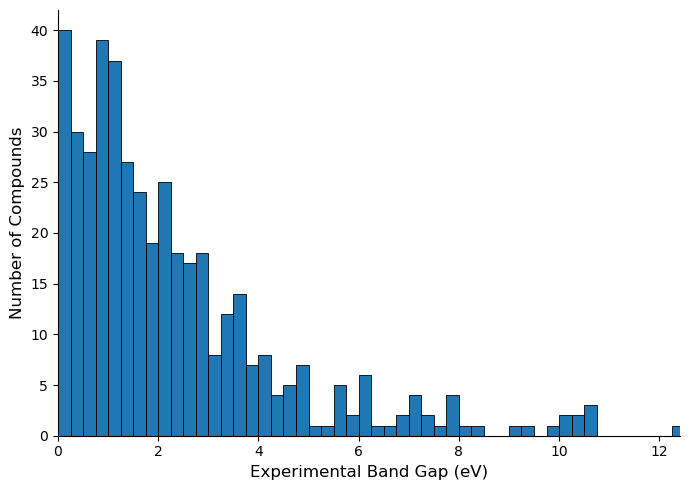

In [10]:
import matplotlib.pyplot as plt
import numpy as np
bandgaps = df_binary["band_gap_experimenatal (eV)"].dropna()

# Bin width: 0.25 eV
bin_width = 0.25
bins = np.arange(0, bandgaps.max() + bin_width, bin_width)

# Plot
plt.figure(figsize=(7, 5))
plt.hist(bandgaps, bins=bins, edgecolor='black', linewidth=0.6)

# Axes labels
plt.xlabel("Experimental Band Gap (eV)", fontsize=12)
plt.ylabel("Number of Compounds", fontsize=12)

# Axis formatting
plt.tick_params(axis='both', labelsize=10)
plt.xlim(0, bandgaps.max())

# Remove top/right spines (journal style)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig("Figure1_Experimental_BandGap_Distribution.png", dpi=300)
plt.show()

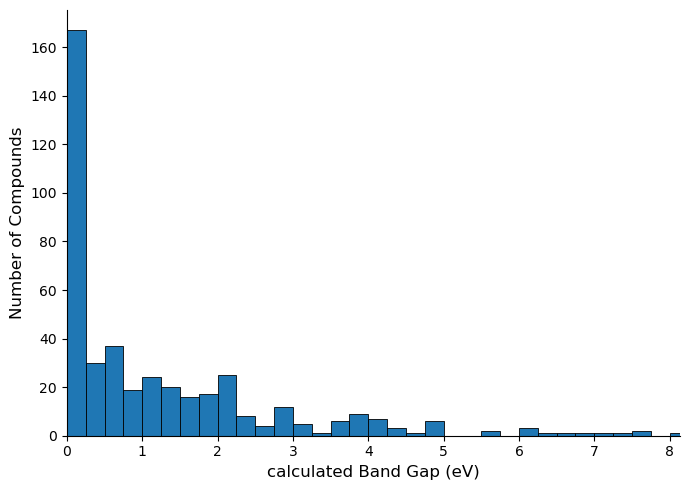

In [11]:
bandgaps = df_binary["band_gap_calculated (eV)"].dropna()

# Bin width: 0.25 eV
bin_width = 0.25
bins = np.arange(0, bandgaps.max() + bin_width, bin_width)

# Plot
plt.figure(figsize=(7, 5))
plt.hist(bandgaps, bins=bins, edgecolor='black', linewidth=0.6)

# Axes labels
plt.xlabel("calculated Band Gap (eV)", fontsize=12)
plt.ylabel("Number of Compounds", fontsize=12)

# Axis formatting
plt.tick_params(axis='both', labelsize=10)
plt.xlim(0, bandgaps.max())

# Remove top/right spines (journal style)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig("Figure1_Experimental_BandGap_Distribution.png", dpi=300)
plt.show()

## Step 5 — Composition Parsing

Each chemical formula is parsed into a normalised atomic fraction dictionary.

**Examples:**
- `GaAs` → `{Ga: 0.5, As: 0.5}`
- `BaCuTeF` → `{Ba: 0.25, Cu: 0.25, Te: 0.25, F: 0.25}`
- `Si` → `{Si: 1.0}`

**Step 5a** — Test the regex pattern on an example formula with LaTeX formatting.

In [12]:
import re
formula =  "Zr$_{7}$Fe$_{92}$B"
clean_formula = formula.replace("$","").replace("_","").replace("{","").replace("}","")
clean_formula
element_concenration_pattern = re.compile("([A-Z][a-z]?)([0-9.]*)")
elem_conc_pairs = element_concenration_pattern.findall(clean_formula)
elem_conc_pairs

[('Zr', '7'), ('Fe', '92'), ('B', '')]

**Step 5b** — Define `remove_characters()`: cleans LaTeX symbols (`$`, `_`, `{`, `}`) from formula strings.

In [13]:
def remove_characters(formula, characters_to_remove="$_{} "):
    clean_formula = formula
    for ch in characters_to_remove:
        clean_formula = clean_formula.replace(ch,"")
    return clean_formula    

**Step 5c** — Define `convert_to_composition_dict()`: converts a clean formula string into a normalised atomic fraction dictionary.

In [14]:
def convert_to_composition_dict(clean_formula):
    try:
        
        elem_conc_pairs = element_concenration_pattern.findall(clean_formula)
        
        
        comp_dict = {}
        for elem, conc_str in elem_conc_pairs:
            if conc_str=="":
                comp_dict[elem] = 1
            else:
                comp_dict[elem]=float(conc_str) 

        conc_sum = 0
        for elem, conc in comp_dict.items():
            conc_sum +=conc
        conc_sum

        for elem, conc in comp_dict.items():
            comp_dict[elem] =conc/conc_sum

        return comp_dict
    except ValueError:
        print("Error when converting: ", clean_formula)
        print("pairs:",elem_conc_pairs)
        return None

**Step 5d** — Apply both parsing functions to every row in the dataset.

In [15]:
df_binary["clean_formula"]=df_binary["formula"].map(remove_characters)
df_binary["comp_dict"]=df_binary["clean_formula"].map(convert_to_composition_dict)
df_binary

,formula,Crystal System,band_gap_calculated (eV),band_gap_experimenatal (eV),clean_formula,comp_dict
0,Ag2O,Cubic,0.000000,1.268500,Ag2O,"{'Ag': 0.6666666666666666, 'O': 0.333333333333..."
1,Ag2S,Cubic,0.000000,1.130000,Ag2S,"{'Ag': 0.6666666666666666, 'S': 0.333333333333..."
2,Ag2S,Monoclinic,1.001344,0.870000,Ag2S,"{'Ag': 0.6666666666666666, 'S': 0.333333333333..."
3,Ag2Se,Cubic,0.090800,0.281667,Ag2Se,"{'Ag': 0.6666666666666666, 'Se': 0.33333333333..."
4,Ag2Se,Orthorhombic,0.334378,0.239125,Ag2Se,"{'Ag': 0.6666666666666666, 'Se': 0.33333333333..."
...,...,...,...,...,...,...
425,ZrO2,Monoclinic,3.850600,2.066667,ZrO2,"{'Zr': 0.3333333333333333, 'O': 0.666666666666..."
426,ZrS2,Trigonal,1.041800,1.760000,ZrS2,"{'Zr': 0.3333333333333333, 'S': 0.666666666666..."
427,ZrS3,Monoclinic,1.113300,2.225000,ZrS3,"{'Zr': 0.25, 'S': 0.75}"
428,ZrSe2,Trigonal,0.329600,2.000000,ZrSe2,"{'Zr': 0.3333333333333333, 'Se': 0.66666666666..."


## Step 6 — Feature Engineering

For each of the 90 elemental properties, three composition-weighted statistics are computed for every compound, yielding **276 features** total:

| Feature Type | Formula | Column prefix |
|---|---|---|
| Weighted average | p̄ₖ = Σ wᵢ pₖ(Eᵢ) | `avg_*` |
| Max–min difference | Δpₖ = max pₖ − min pₖ | `diff_*` |
| Weighted variance | σ²ₖ = Σ wᵢ(pₖ(Eᵢ) − p̄ₖ)² | `var_*` |

The `avg_*` features capture the average elemental environment.  
The `diff_*` features capture elemental contrast (e.g., electronegativity difference).  
The `var_*` features capture chemical heterogeneity within the compound.

In [16]:
import pandas as pd
import numpy as np
import ast # Used to convert strings to dictionaries

# --- 1. SET YOUR COLUMN/DATAFRAME NAMES ---
df_binary = df_binary  # Your compounds (with 'comp_dict')
df= df  # Your elements (with properties)
parsed_col_name = "comp_dict" 
formula_col_name = "formula" # The column in df2 with "H", "Si", etc.

# --- 2. CLEAN df_binary ---
# This converts the string "{'S': 1.0}" into a real dictionary {'S': 1.0}
# and cleans the keys (e.g., "S " -> "S")
def convert_and_clean_dict(dict_string):
    try:
        comp_dict = ast.literal_eval(str(dict_string))
        if not isinstance(comp_dict, dict):
            return np.nan
        cleaned_dict = {}
        for element, fraction in comp_dict.items():
            if isinstance(element, str):
                cleaned_key = element.strip()
                cleaned_dict[cleaned_key] = fraction
            else:
                return np.nan
        return cleaned_dict
    except (ValueError, SyntaxError, TypeError):
        return np.nan

print("Cleaning df_binary 'comp_dict' column...")
df_binary[parsed_col_name] = df_binary[parsed_col_name].apply(convert_and_clean_dict)
df_binary = df_binary.dropna(subset=[parsed_col_name]) # Drop rows that failed conversion
print("df_binary cleaning complete.")

# --- 3. CLEAN AND SET INDEX FOR Elements database ---
# This sets the index to the 'formula' column AND cleans it
try:
    # If 'formula' is already the index, just clean it
    if df.index.name == formula_col_name:
        df.index = df.index.astype(str).str.strip()
        print(f"df index '{formula_col_name}' was already set. Index cleaned.")
    # If 'formula' is a column, set it as the index and clean it
    elif formula_col_name in df.columns:
        df = df.set_index(formula_col_name)
        df.index = df.index.astype(str).str.strip()
        print(f"df index set to '{formula_col_name}' and cleaned.")
    else:
        # If 'formula' is not the index or a column, we have a problem.
        # This might be your case. RELOAD df2 if this error appears.
        print(f"Error: Column or Index '{formula_col_name}' not found in df.")
        print("Please RELOAD your df dataframe from its file and try again.")
        
except Exception as e:
    print(f"An error occurred setting up df: {e}")


# --- 4. HELPER FUNCTIONS (The FAST version, uses INDEX) ---

def get_weighted_avg(comp_dict, property_name, df_elements):
    total_avg = 0
    try:
        for element, fraction in comp_dict.items():
            # Uses .loc[] for fast index lookup
            prop_value = df_elements.loc[element, property_name] 
            if pd.isna(prop_value):
                return np.nan 
            total_avg += fraction * prop_value
        return total_avg
    except KeyError as e:
        # This element is truly missing from df2
        return np.nan 
    except TypeError:
        return np.nan

def get_difference(comp_dict, property_name, df_elements):
    values = []
    try:
        for element in comp_dict.keys():
            prop_value = df_elements.loc[element, property_name]
            if pd.isna(prop_value):
                return np.nan
            values.append(prop_value)
        if not values:
            return 0
        return max(values) - min(values)
    except (KeyError, AttributeError, TypeError):
        return np.nan

def get_weighted_variance(comp_dict, property_name, mean_val, df_elements):
    if pd.isna(mean_val):
        return np.nan
    total_var = 0
    try:
        for element, fraction in comp_dict.items():
            prop_value = df_elements.loc[element, property_name]
            if pd.isna(prop_value):
                return np.nan
            total_var += fraction * ((prop_value - mean_val) ** 2)
        return total_var
    except (KeyError, AttributeError, TypeError):
        return np.nan

# --- 5. MAIN FEATURE ENGINEERING LOOP ---

property_list = df.columns # Get all property columns

df_binary = df_binary.copy()  # Defragment DataFrame to avoid PerformanceWarning

print(f"Starting feature engineering for {len(property_list)} properties...")

for prop in property_list:
    avg_col_name = f'avg_{prop}'
    df_binary[avg_col_name] = df_binary[parsed_col_name].apply(
        lambda comp: get_weighted_avg(comp, prop, df)
    )
    
    diff_col_name = f'diff_{prop}'
    df_binary[diff_col_name] = df_binary[parsed_col_name].apply(
        lambda comp: get_difference(comp, prop, df)
    )
    
    var_col_name = f'var_{prop}'
    df_binary[var_col_name] = df_binary.apply(
        lambda row: get_weighted_variance(row[parsed_col_name], prop, row[avg_col_name], df),
        axis=1
    )

print("--- Feature engineering complete! ---")

# --- 6. CHECK YOUR RESULTS ---
print("Checking for NaN values in a new feature column...")
if not property_list.empty:
    check_col = f'avg_{property_list[0]}' 
    nan_percentage = df_binary[check_col].isna().mean() * 100
    print(f"Percentage of NaN in '{check_col}': {nan_percentage:.2f}%")

    if nan_percentage < 100:
        print("\nSuccess! Non-NaN values were calculated.")
    else:
        print("\nFailure: Still 100% NaN. Elements like 'C', 'P', 'S' may be missing from df2.")
else:
    print("Error: No property columns found in df.")

print("\nFinal df_binary head:")
print(df_binary.head())

Cleaning df_binary 'comp_dict' column...
df_binary cleaning complete.
df index 'formula' was already set. Index cleaned.
Starting feature engineering for 90 properties...


/tmp/ipykernel_196227/371957747.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_binary[var_col_name] = df_binary.apply(
/tmp/ipykernel_196227/371957747.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_binary[avg_col_name] = df_binary[parsed_col_name].apply(
/tmp/ipykernel_196227/371957747.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To

--- Feature engineering complete! ---
Checking for NaN values in a new feature column...
Percentage of NaN in 'avg_atomic_number': 0.00%

Success! Non-NaN values were calculated.

Final df_binary head:
  formula Crystal System  band_gap_calculated (eV)  \
0    Ag2O          Cubic                  0.000000   
1    Ag2S          Cubic                  0.000000   
2    Ag2S     Monoclinic                  1.001344   
3   Ag2Se          Cubic                  0.090800   
4   Ag2Se   Orthorhombic                  0.334378   

   band_gap_experimenatal (eV) clean_formula  \
0                     1.268500          Ag2O   
1                     1.130000          Ag2S   
2                     0.870000          Ag2S   
3                     0.281667         Ag2Se   
4                     0.239125         Ag2Se   

                                           comp_dict  avg_atomic_number  \
0  {'Ag': 0.6666666666666666, 'O': 0.333333333333...          34.000000   
1  {'Ag': 0.6666666666666666, 'S':

/tmp/ipykernel_196227/371957747.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_binary[var_col_name] = df_binary.apply(
/tmp/ipykernel_196227/371957747.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_binary[avg_col_name] = df_binary[parsed_col_name].apply(
/tmp/ipykernel_196227/371957747.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To

In [17]:
df_binary

,formula,Crystal System,band_gap_calculated (eV),band_gap_experimenatal (eV),clean_formula,comp_dict,avg_atomic_number,diff_atomic_number,var_atomic_number,avg_periodic_number_bottom_up,...,var_delta_h_interface_o_in_m_miedema,avg_delta_h_interface_m_in_o_miedema,diff_delta_h_interface_m_in_o_miedema,var_delta_h_interface_m_in_o_miedema,avg_delta_h_interface_m_in_s_miedema,diff_delta_h_interface_m_in_s_miedema,var_delta_h_interface_m_in_s_miedema,avg_oxidation_state_first,diff_oxidation_state_first,var_oxidation_state_first
0,Ag2O,Cubic,0.000000,1.268500,Ag2O,"{'Ag': 0.6666666666666666, 'O': 0.333333333333...",34.000000,39.0,338.000000,73.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,2.00
1,Ag2S,Cubic,0.000000,1.130000,Ag2S,"{'Ag': 0.6666666666666666, 'S': 0.333333333333...",36.666667,31.0,213.555556,70.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,2.00
2,Ag2S,Monoclinic,1.001344,0.870000,Ag2S,"{'Ag': 0.6666666666666666, 'S': 0.333333333333...",36.666667,31.0,213.555556,70.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,2.00
3,Ag2Se,Cubic,0.090800,0.281667,Ag2Se,"{'Ag': 0.6666666666666666, 'Se': 0.33333333333...",42.666667,13.0,37.555556,67.666667,...,1530.888889,-95.00,240.0,12800.0000,NaN,NaN,NaN,0.0,3.0,2.00
4,Ag2Se,Orthorhombic,0.334378,0.239125,Ag2Se,"{'Ag': 0.6666666666666666, 'Se': 0.33333333333...",42.666667,13.0,37.555556,67.666667,...,1530.888889,-95.00,240.0,12800.0000,NaN,NaN,NaN,0.0,3.0,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,ZrO2,Monoclinic,3.850600,2.066667,ZrO2,"{'Zr': 0.3333333333333333, 'O': 0.666666666666...",18.666667,32.0,227.555556,83.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,6.0,8.00
426,ZrS2,Trigonal,1.041800,1.760000,ZrS2,"{'Zr': 0.3333333333333333, 'S': 0.666666666666...",24.000000,24.0,128.000000,78.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,6.0,8.00
427,ZrS3,Monoclinic,1.113300,2.225000,ZrS3,"{'Zr': 0.25, 'S': 0.75}",22.000000,24.0,108.000000,81.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.5,6.0,6.75
428,ZrSe2,Trigonal,0.329600,2.000000,ZrSe2,"{'Zr': 0.3333333333333333, 'Se': 0.66666666666...",36.000000,6.0,8.000000,73.000000,...,42243.555556,-536.00,843.0,157922.0000,NaN,NaN,NaN,0.0,6.0,8.00


## Step 7 — Data Preparation & Train/Test Split

Before training:
- Target variable: `band_gap_experimenatal (eV)` (experimental band gap)
- Features: 276 CBFV descriptors + `band_gap_calculated (eV)` (DFT baseline as a feature)
- Infinite and missing values replaced with column means (`SimpleImputer`)
- **80/20 train/test split** (`random_state=42`) — 20% is held out and never used during CV
- 10-Fold Cross-Validation is applied **only within the training set** to avoid data leakage

---

## Step 8 — Model Benchmarking (10-Fold Cross-Validation)

All 12 regression algorithms are evaluated with **identical 10-Fold CV splits** for fair comparison.  
Models are grouped by type:

**8a — XGBoost (Gradient Boosted Trees)**  
Optimised gradient boosting with histogram-based splits. Testing multiple `n_estimators` and `max_depth` configurations.

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# --- 1. Define Your Features (X) and Target (y) ---

# Your target (Y) is the experimental bandgap
target_col = 'band_gap_experimenatal (eV)' 

# Your features (X) are all the columns you engineered,
# PLUS the 'band_gap_calculated'
# We must exclude non-numeric or leaky columns.

# First, drop any rows where your target is missing
df_binary_cleaned = df_binary.dropna(subset=[target_col])

# Get a list of all your new feature columns
feature_cols = [col for col in df_binary_cleaned.columns if col.startswith(('avg_', 'diff_', 'var_'))]

# Don't forget your most important feature!
feature_cols.append('band_gap_calculated (eV)') 

# Create X and y
X = df_binary_cleaned[feature_cols]
y = df_binary_cleaned[target_col]

print(f"Using {len(feature_cols)} features.")
print(f"Training on {X.shape[0]} samples.")

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# --- 2. Handle Missing, Infinite, and Extreme Values (FIXED) ---

print("Starting Step 2: Cleaning features...")

# First, replace all infinite values (positive and negative) with NaN
# This is the critical line.
X = X.replace([np.inf, -np.inf], np.nan)
print("Replaced 'inf' values with 'nan'.")

cols_all_nan = X.columns[X.isna().all()]
X = X.drop(columns=cols_all_nan)
print("Dropped all-NaN columns:", list(cols_all_nan))

# Now, the imputer will fill both NaNs (from missing elements)
# and NaNs (that were 'inf') with the column mean.
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
print("Imputed 'nan' values with column means.")

# Convert back to DataFrame
X = pd.DataFrame(X_imputed, columns=X.columns)

# --- !! NEW SAFETY CHECK !! ---
# This fixes the "...or a value too large for dtype('float32')" part.

# Get the maximum and minimum values a float32 can hold
finfo = np.finfo(np.float32)

#  Replace any 'inf' values that the imputer might have created
X = X.replace([np.inf, -np.inf], np.nan) 

#  Clip all values to be within the valid float32 range
X = X.clip(finfo.min, finfo.max)

#  Fill any remaining NaNs (if a whole column was bad) with 0
X = X.fillna(0)
print("Clipped extreme values and filled any final NaNs.")


# --- 3. Split Data into Training and Testing Sets ---
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import numpy as np

X_train_arr = np.array(X_train)
y_train_arr = np.array(y_train)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

model = XGBRegressor(tree_method='hist', n_estimators=100, max_depth=3, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)


print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Using 271 features.
Training on 430 samples.
Starting Step 2: Cleaning features...
Replaced 'inf' values with 'nan'.
Dropped all-NaN columns: []
Imputed 'nan' values with column means.
Clipped extreme values and filled any final NaNs.
Training set size: 344
Testing set size: 86
R2: 0.7839561990112138
MAE: 0.6914352361621355
RMSE: 1.0354646711763666


In [19]:
model = XGBRegressor(tree_method='hist', n_estimators=200, max_depth=3, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7810530474091189
MAE: 0.696548671973359
RMSE: 1.0423986339212468


In [20]:
model = XGBRegressor(tree_method='hist', n_estimators=300, max_depth=3, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7804840585605175
MAE: 0.6976297675114851
RMSE: 1.0437522228907041


In [21]:
model = XGBRegressor(tree_method='hist', n_estimators=50, max_depth=3, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7906621924911743
MAE: 0.6848384992094025
RMSE: 1.0192675941159215


In [22]:
model = XGBRegressor(tree_method='hist', n_estimators=25, max_depth=3, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7967672670648936
MAE: 0.6847697603900427
RMSE: 1.004294790178374


In [23]:
model = XGBRegressor(tree_method='hist', n_estimators=25, max_depth=5, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7841945040407509
MAE: 0.6968810953173178
RMSE: 1.0348934339525928


**8b — Random Forest**  
Ensemble of decision trees trained with bootstrap sampling. Testing multiple `n_estimators` configurations.

In [24]:
model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8148122136784648
MAE: 0.6771505066757705
RMSE: 0.9586731217911761


In [25]:
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8145862241565398
MAE: 0.6770240100321704
RMSE: 0.9592578904444712


In [26]:
model = RandomForestRegressor(n_estimators=100, random_state=21, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8087158663969205
MAE: 0.685729342615716
RMSE: 0.9743250203481051


In [27]:
model = RandomForestRegressor(n_estimators=50, random_state=21, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8000760296187402
MAE: 0.6953049916539401
RMSE: 0.9960859519056838


**8c — Gradient Boosting (sklearn)**  
Sequential tree boosting that corrects residuals. Testing multiple `n_estimators` and `max_depth` combinations.

In [28]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8118629135920715
MAE: 0.6486130008488074
RMSE: 0.9662768795422785


In [29]:
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8035864365798472
MAE: 0.6586169253567332
RMSE: 0.9873022314071082


In [30]:
model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=3)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7998136459329789
MAE: 0.6652765793005013
RMSE: 0.9967393778226854


In [31]:
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8037422295602613
MAE: 0.6744347989388977
RMSE: 0.986910595341736


**8d — Linear & Regularized Models**  
Interpretable baselines: Linear Regression and Ridge Regression (L2 regularisation). These models assume a linear relationship between features and band gap.

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LinearRegression()
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.13365058682179876
MAE: 1.4967574455148411
RMSE: 2.07353286830948


In [33]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = Ridge(alpha=1.0)  # alpha = regularization strength

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))   

R2: 0.6744484449470219
MAE: 0.8583490063237857
RMSE: 1.2554807581609497


In [34]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = Ridge(alpha=2.0)  # alpha = regularization strength

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))   

R2: 0.7193774865781237
MAE: 0.8171514715444121
RMSE: 1.1656319124426584


**8e — Support Vector Regression (SVR)**  
RBF kernel SVR constructs a flexible nonlinear regression function. Requires feature standardisation.

In [35]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7198408305708466
MAE: 0.7754710522916113
RMSE: 1.1646692105179552


**8f — k-Nearest Neighbors (k-NN)**  
Predicts using the weighted average of the k closest compounds in feature space. Testing k = 5, 10, 15.

In [36]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KNeighborsRegressor(n_neighbors=5)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7761272148399994
MAE: 0.7372963085511627
RMSE: 1.0411200854551723


In [37]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KNeighborsRegressor(n_neighbors=10)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7240525049569537
MAE: 0.8434926475360464
RMSE: 1.155881737033624


In [38]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KNeighborsRegressor(n_neighbors=15)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.6600444593520138
MAE: 0.9486249237593798
RMSE: 1.282954445038778


**8g — Bayesian Ridge Regression**  
Uses Gaussian priors on coefficients for uncertainty-aware predictions and automatic regularisation.

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = BayesianRidge()
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8058773618423224
MAE: 0.7087446286709627
RMSE: 0.9694786876888924


**8h — MLP Neural Network**  
Multi-layer perceptron with two hidden layers (100, 50 neurons) and ReLU activation. Captures highly nonlinear relationships.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import KFold
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np



y_true, y_pred = [], []

model = MLPRegressor(hidden_layer_sizes=(100,50), max_iter=1500, random_state=42, learning_rate_init=0.001)

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7784651909940532
MAE: 0.7393890475636135
RMSE: 1.0356694399151676


In [41]:


model = MLPRegressor(hidden_layer_sizes=(100,50), max_iter=1000, random_state=42, learning_rate_init=0.001)
y_true, y_pred = [], []
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7784651909940532
MAE: 0.7393890475636135
RMSE: 1.0356694399151676


**8i — Extra Trees Regressor** ⭐ *Best Model*  
Similar to Random Forest but uses **random thresholds** instead of optimal splits — faster training, often better generalisation.  
**This is the best-performing model for binary compounds compounds: ExtraTrees (n_estimators=300) → R² = 0.8271, MAE = 0.6225 eV**

In [42]:
from sklearn.ensemble import ExtraTreesRegressor

# Model
model = ExtraTreesRegressor(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8222290882122818
MAE: 0.6294167518301452
RMSE: 0.9392792561086921


In [43]:
from sklearn.ensemble import ExtraTreesRegressor

# Model
model = ExtraTreesRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8269368943818202
MAE: 0.6211266651247673
RMSE: 0.9267586058465173


In [44]:
from sklearn.ensemble import ExtraTreesRegressor

# Model
model = ExtraTreesRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8270896723174341
MAE: 0.6224925063501453
RMSE: 0.9263494500995603


## Step 9 — Feature Importance Analysis

Feature importances from the trained Extra Trees model show which physical descriptors drive predictions.  
The dominant feature (`var_oxidation_state_first`) encodes **ionicity** — greater oxidation state variance → stronger cation–anion interactions → wider band gap.  
Mendeleev number differences encode electronegativity and atomic radius contrasts.

X columns: 271
Feature names: 271
MATCH! Generating plot...


/tmp/ipykernel_196227/36421814.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')


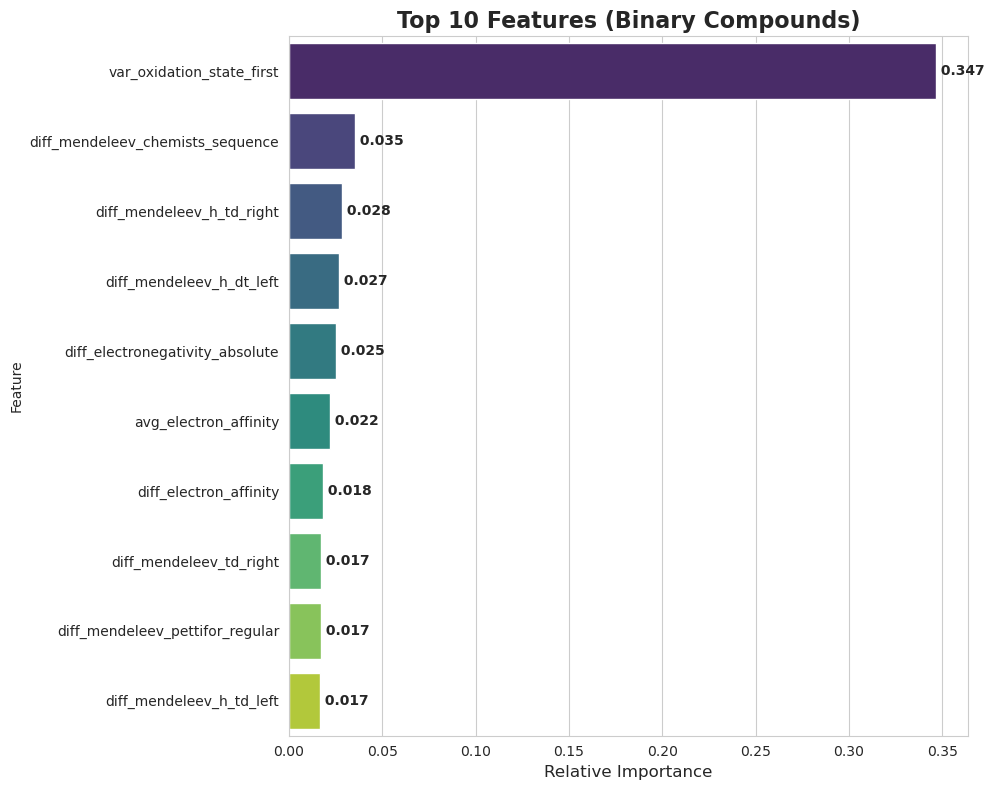

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. CORRECTED LIST (Removed 'band_gap_calculated (eV)') ---
# We ONLY exclude the text columns and the TARGET (Experimental Gap).
# We KEEP 'band_gap_calculated (eV)' because it is a feature in X.
non_features = ['formula', 'band_gap_experimenatal (eV)', 
                'Crystal System', 'clean_formula', 'comp_dict']

# Get the feature names
feature_names = [col for col in df_binary_cleaned.columns if col not in non_features]

# --- 2. VERIFY ALIGNMENT ---
print(f"X columns: {X.shape[1]}")
print(f"Feature names: {len(feature_names)}")

if X.shape[1] == len(feature_names):
    print("MATCH! Generating plot...")
    
    # --- 3. TRAIN AND PLOT ---
    model.fit(X, y)
    importances = model.feature_importances_

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    # Sort
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    # Plot Top 10
    plt.figure(figsize=(10, 8))
    sns.set_style("whitegrid")
    
    top_10 = feature_importance_df.head(10)
    sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')

    plt.title('Top 10 Features (Binary Compounds)', fontsize=16, fontweight='bold')
    plt.xlabel('Relative Importance', fontsize=12)
    
    # Add values
    for index, value in enumerate(top_10['Importance']):
        plt.text(value, index, f' {value:.3f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('binary 10 feature', dpi=300)
    plt.show()
    
else:
    print("\nSTILL MISMATCHED!")
    print("Trying to find the missing column...")
    # Helper to find what is extra
    all_cols = set(df_binary_cleaned.columns)
    kept_cols = set(feature_names)
    dropped = all_cols - kept_cols
    print(f"Columns currently excluded: {dropped}")
    print("Check if one of these is actually inside your X variable.")

    

## Step 10 — Parity Plot: Predicted vs. Experimental Band Gap

Scatter plot of out-of-fold CV predictions against experimental values.  
Points close to the red dashed diagonal (y = x) indicate accurate predictions.  
The model is most precise in the 0–3 eV range (common semiconductors); some scatter appears for wide-gap insulators (> 4 eV).

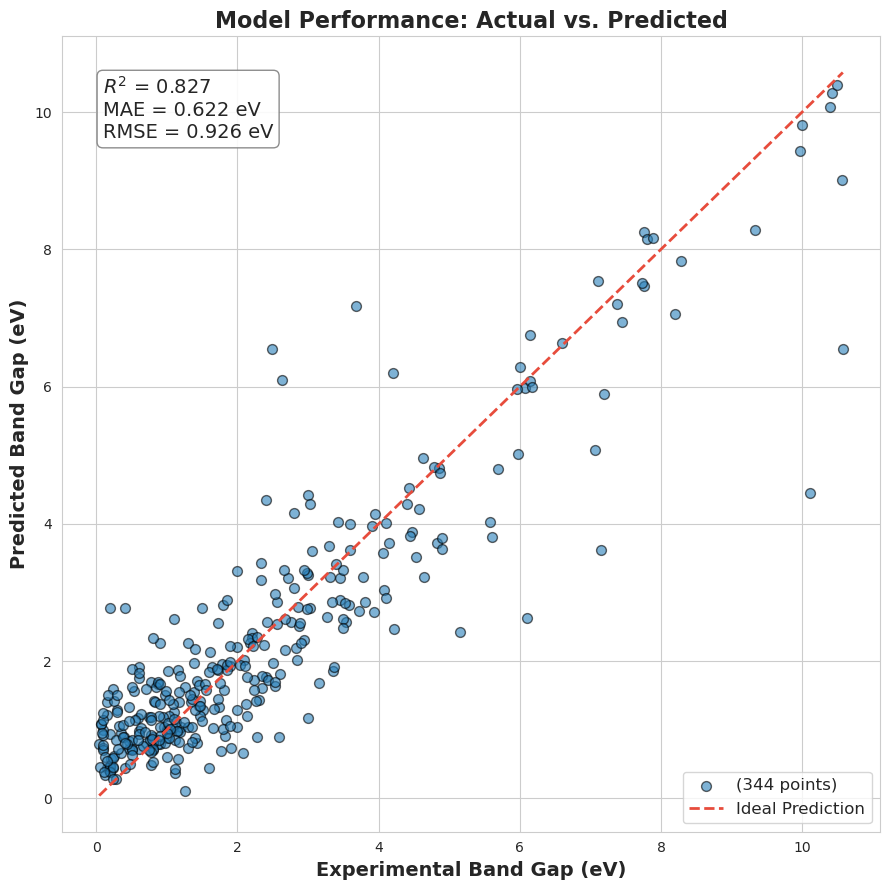

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- 1. PREPARE DATA ---
# Convert your lists to numpy arrays (easiest for plotting)
actual_values = np.array(y_true)
predicted_values = np.array(y_pred)

# Optional: Fix any negative predictions to 0.0 (Physics fix)
predicted_values = np.maximum(predicted_values, 0.0)

# --- 2. CALCULATE METRICS (For the label) ---
r2 = r2_score(actual_values, predicted_values)
mae = mean_absolute_error(actual_values, predicted_values)
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))

# --- 3. GENERATE THE PLOT ---
plt.figure(figsize=(9, 9))
sns.set_style("whitegrid")

# The Scatter Plot
plt.scatter(actual_values, predicted_values, 
            alpha=0.6, 
            color='#2980b9', 
            edgecolor='k', 
            s=50, 
            label=f'({len(actual_values)} points)')

# The "Perfect Prediction" Red Dashed Line (y=x)
min_val = min(actual_values.min(), predicted_values.min())
max_val = max(actual_values.max(), predicted_values.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='#e74c3c', 
         linestyle='--', 
         linewidth=2, 
         label='Ideal Prediction')

# --- 4. LABELS AND BOX ---
plt.xlabel('Experimental Band Gap (eV)', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Band Gap (eV)', fontsize=14, fontweight='bold')
plt.title('Model Performance: Actual vs. Predicted', fontsize=16, fontweight='bold')

# Add the Score Box
text_str = f'$R^2$ = {r2:.3f}\nMAE = {mae:.3f} eV\nRMSE = {rmse:.3f} eV'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=14,
         verticalalignment='top', bbox=props)

plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()

# Save and Show
plt.savefig('binary_exp vs predicted.png', dpi=300)
plt.show()

## Step 11 — Monte Carlo Cross-Validation (Robustness Test)

To confirm that the CV performance is not a result of a lucky random split, the best model is evaluated 20 times with different random partitions.  
Each iteration holds out **10 random samples** as a blind validation set.  
If MAE stays stable across all 20 runs, it confirms the model captures genuine physical trends.

In [47]:
from sklearn.model_selection import ShuffleSplit

# --- 1. SETUP THE REPEATED TEST ---
# n_splits=50  -> We will do this test 20 times
# test_size=10 -> Every time, we pick exactly 10 random points for testing
ss = ShuffleSplit(n_splits=20, test_size=10, random_state=42)

# Lists to save the score of each round
scores_r2 = []
scores_mae = []
scores_rmse = []

# Convert to numpy arrays (safer for splitting)
X_arr = np.array(X)
y_arr = np.array(y)

model = ExtraTreesRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)


print("Starting Repeated 10-Point Testing (20 Rounds)...")

# --- 2. THE LOOP ---
for train_index, test_index in ss.split(X_arr):
    
    # Create the split for this specific round
    X_train, X_test = X_arr[train_index], X_arr[test_index]
    y_train, y_test = y_arr[train_index], y_arr[test_index]
    
    # Train
    model.fit(X_train, y_train)
    
    # Test
    y_pred = model.predict(X_test)
    
    # Calculate Scores for this round and save them
    scores_r2.append(r2_score(y_test, y_pred))
    scores_mae.append(mean_absolute_error(y_test, y_pred))
    scores_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))

# --- 3. FINAL RESULTS (AVERAGE) ---
print("\n--- FINAL ROBUST RESULTS (Average of 20 runs) ---")
print(f"Average R2:   {np.mean(scores_r2):.4f}")
print(f"Average MAE:  {np.mean(scores_mae):.4f}")
print(f"Average RMSE: {np.mean(scores_rmse):.4f}")



Starting Repeated 10-Point Testing (20 Rounds)...

--- FINAL ROBUST RESULTS (Average of 20 runs) ---
Average R2:   0.7339
Average MAE:  0.6110
Average RMSE: 0.8339


## Step 12 — Leave-One-Group-Out Validation (Generalization Test)

The strictest test: the model is trained on all compounds **except** those containing a specific element family, then evaluated on that completely unseen family.  
This simulates a real materials discovery scenario — predicting properties of new, unknown chemical systems.  
Sub-eV MAE here means the model has learned transferable physical principles (electronegativity, ionicity), not formula memorisation.

In [48]:
from sklearn.model_selection import LeaveOneGroupOut


# --- 3. Find the "Compound Element" for Grouping ---
# This finds the last element in the formula (e.g. 'BaZn2As2' -> 'As')
def get_main_element(formula):
    elements = re.findall(r'[A-Z][a-z]*', str(formula))
    return elements[-1] if elements else 'Unknown'

groups = df_binary_cleaned['formula'].apply(get_main_element).values

# --- 4. The Professor's Test: Train on Mixed, Test on Unseen Element ---
X_arr = np.array(X)
y_arr = np.array(y)

# LeaveOneGroupOut splits the data by the Compound Element automatically
logo = LeaveOneGroupOut()
model = ExtraTreesRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

print("Starting Testing (Training on mixed, testing on unseen elements)...\n")

for train_index, test_index in logo.split(X_arr, y_arr, groups):

    test_element = groups[test_index[-1]]
    
    # We skip elements that only have 1 or 2 rows (too small to reliably test)
    if len(test_index) < 3:
        continue

        # ==========================================
    # --- THE "SPY BLOCK" (See what it's doing) ---
    # ==========================================
    print(f"\n--- ROUND: Hidden Element is [{test_element}] ---")
    
    # Find the actual chemical formulas going into the TEST set
    test_formulas = df_binary_cleaned.iloc[test_index]['formula'].unique()
    print(f"TESTING on {len(test_index)} compounds. Examples: {test_formulas[:5]}") 
    
    # Check what elements are in the TRAIN set to prove the test_element is missing
    train_elements = np.unique(groups[train_index])
    is_leaking = test_element in train_elements
    print(f"TRAINING on {len(train_index)} compounds.")
    print(f"Is '{test_element}' hiding in the Training set? {'Yes (ERROR!)' if is_leaking else 'No (Perfect!)'}")
    # ==========================================
        
    # Train the model
    model.fit(X_arr[train_index], y_arr[train_index])
    
    # Predict on the unseen element group
    predictions = model.predict(X_arr[test_index])
    
    # Save results
    y_true.extend(y_arr[test_index])
    y_pred.extend(predictions)

# --- 5. Print Final Results ---
print("--- FINAL RESULT ON UNSEEN ELEMENTS ---")
print("Total R2:   ", r2_score(y_true, y_pred))
print("Total MAE:  ", mean_absolute_error(y_true, y_pred))
print("Total RMSE: ", np.sqrt(mean_squared_error(y_true, y_pred)))

Starting Testing (Training on mixed, testing on unseen elements)...


--- ROUND: Hidden Element is [As] ---
TESTING on 28 compounds. Examples: ['AlAs' 'BAs' 'Cd3As2' 'CdAs2' 'CoAs2']
TRAINING on 402 compounds.
Is 'As' hiding in the Training set? No (Perfect!)

--- ROUND: Hidden Element is [B] ---
TESTING on 9 compounds. Examples: ['CaB6' 'DyB6' 'ErB6' 'GdB6' 'LaB6']
TRAINING on 421 compounds.
Is 'B' hiding in the Training set? No (Perfect!)

--- ROUND: Hidden Element is [Bi] ---
TESTING on 6 compounds. Examples: ['Cs3Bi' 'CsBi2' 'K3Bi' 'Li3Bi' 'Mg3Bi2']
TRAINING on 424 compounds.
Is 'Bi' hiding in the Training set? No (Perfect!)

--- ROUND: Hidden Element is [Br] ---
TESTING on 15 compounds. Examples: ['AgBr' 'AsBr3' 'BiBr3' 'CBr4' 'CdBr2']
TRAINING on 415 compounds.
Is 'Br' hiding in the Training set? No (Perfect!)

--- ROUND: Hidden Element is [Cl] ---
TESTING on 11 compounds. Examples: ['AgCl' 'CsCl' 'CuCl' 'HgCl2' 'KCl']
TRAINING on 419 compounds.
Is 'Cl' hiding in the Training set

**8j — CatBoost**  
Gradient boosting optimised for categorical features. Uses ordered boosting to mitigate overfitting. Testing multiple `n_estimators` and `depth` configurations.

In [49]:
from catboost import CatBoostRegressor

# Model
model = CatBoostRegressor(n_estimators=200, learning_rate=0.1, depth=5, verbose=0, random_state=42)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.815614097999651
MAE: 0.6392402792929716
RMSE: 0.956595287837244


In [50]:
from catboost import CatBoostRegressor

# Model
model = CatBoostRegressor(n_estimators=300, learning_rate=0.1, depth=5, verbose=0, random_state=42)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8128458750246816
MAE: 0.6379712614553785
RMSE: 0.9637493162653336


In [51]:
from catboost import CatBoostRegressor

# Model
model = CatBoostRegressor(n_estimators=100, learning_rate=0.1, depth=5, verbose=0, random_state=42)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.8182824132387834
MAE: 0.6573124311187761
RMSE: 0.9496484450599645


**8k — Decision Tree**  
Single tree with recursive splits. Interpretable but prone to overfitting. Testing multiple `max_depth` values.

In [52]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=6, random_state=42)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.6838714459752375
MAE: 0.8393813048598435
RMSE: 1.2525533809379765


In [53]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=3, random_state=42)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.6891661952422459
MAE: 0.8660713566979161
RMSE: 1.2420197543158997


In [54]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=10, random_state=42)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.6797131653976765
MAE: 0.8429684762442308
RMSE: 1.2607643639667778


In [55]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=15, random_state=42)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
   
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    
    predictions = model.predict(X_train_arr[test_index])
    
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.6710811277049924
MAE: 0.8767707706843051
RMSE: 1.2776408158310113
